# Day 05 — Ghép toàn bộ pipeline thành báo cáo phân tích

[Slide của buổi học](_static/slides/day05_slides.pptx)

## Mục tiêu

- Ghép lại toàn bộ output từ Day 01 đến Day 04
- Lưu bảng và hình vào thư mục rõ ràng
- Viết một đoạn tóm tắt kết quả ngay trong notebook
- Chuẩn bị vật liệu để đưa vào báo cáo hoặc poster

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, brier_score_loss
from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.stats import mannwhitneyu

GITHUB_USER = "ketnoimaytinh797-dotcom"
REPO_NAME = "EGFR-Radiomics-MiniBootcamp"
BRANCH = "main"

def raw_url(relative_path):
    return f"https://raw.githubusercontent.com/{GITHUB_USER}/{REPO_NAME}/{BRANCH}/{relative_path}"

def load_csv(relative_repo_path):
    local_candidates = [
        Path(relative_repo_path),
        Path("..") / relative_repo_path,
        Path("/content") / REPO_NAME / relative_repo_path,
    ]
    for p in local_candidates:
        if p.exists():
            return pd.read_csv(p)
    return pd.read_csv(raw_url(relative_repo_path))

def build_lr_pipeline(feature_list, cat_cols):
    num_cols = [c for c in feature_list if c not in cat_cols]
    pre = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), [c for c in feature_list if c in cat_cols]),
    ])
    pipe = Pipeline([
        ("pre", pre),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    return pipe

In [2]:
from pathlib import Path
import json

df = load_csv('data/nsclc_egfr_radiomics_simplified.csv')
ngs = load_csv('data/ngs_pathway_demo_64.csv')

output_dir = Path('output/day05')
output_dir.mkdir(parents=True, exist_ok=True)

with open('_static/downloads/demo_metrics.json', encoding='utf-8') as f:
    metrics = json.load(f)

display(pd.DataFrame({
    'Mốc chính': ['Cohort', 'EGFR dương', 'ROI tốt nhất', 'Mean CV AUC', 'Bootstrap CI thấp', 'Bootstrap CI cao', 'Pathway đứng đầu'],
    'Giá trị': [
        metrics['cohort_n'],
        metrics['egfr_positive_pct'],
        'ring1',
        metrics['cv_auc_mean'],
        metrics['bootstrap_ci'][0],
        metrics['bootstrap_ci'][1],
        metrics['top_pathway']
    ]
}))

,Mốc chính,Giá trị
0,Cohort,200
1,EGFR dương,45.5
2,ROI tốt nhất,ring1
3,Mean CV AUC,0.81
4,Bootstrap CI thấp,0.687
5,Bootstrap CI cao,0.923
6,Pathway đứng đầu,PI3K


## Bước 1 — Gom các bảng chính

Buổi này không phát minh thêm chỉ số mới. Mục tiêu là sắp xếp lại sản phẩm để có thể đưa thẳng vào báo cáo.

In [3]:
roi_results = pd.read_csv('_static/downloads/day02_roi_results.csv')
cv_results = pd.read_csv('_static/downloads/day03_cv_auc.csv')
pathway_results = pd.read_csv('_static/downloads/day04_pathway_delta_p.csv')

roi_results.to_csv(output_dir / 'roi_results.csv', index=False)
cv_results.to_csv(output_dir / 'cv_results.csv', index=False)
pathway_results.to_csv(output_dir / 'pathway_results.csv', index=False)

display(roi_results)
display(cv_results)
display(pathway_results.head())

,roi,auc,brier,sensitivity,specificity,threshold,accuracy
0,intra,0.694042,0.225683,0.956522,0.333333,0.160097,0.62
1,ring1,0.814815,0.192136,0.869565,0.740741,0.282731,0.80
2,ring3,0.747182,0.216297,0.869565,0.592593,0.206884,0.72
3,ring5,0.747182,0.214199,0.608696,0.814815,0.429298,0.72


,fold,auc
0,1,0.746867
1,2,0.833333
2,3,0.785354
3,4,0.777778
4,5,0.909091


,pathway,n_mut,n_wt,median_mut,median_wt,delta_median_p,mean_mut,mean_wt,delta_mean_p,mannwhitney_p
0,PI3K,24,40,0.611674,0.378279,0.233395,0.569379,0.410821,0.158558,0.084257
1,Cell_cycle,24,40,0.482234,0.386710,0.095525,0.493176,0.456542,0.036634,0.662237
2,DNA_repair,19,45,0.482277,0.425738,0.056540,0.544078,0.439121,0.104957,0.370062
3,RTK_RAS,22,42,0.410459,0.430748,-0.020289,0.464212,0.473459,-0.009247,0.870870
4,TP53,28,36,0.404034,0.436506,-0.032472,0.451466,0.484913,-0.033447,0.719870


## Bước 2 — Gom hình chính

Ở đây dùng lại các hình đã có từ các buổi trước.

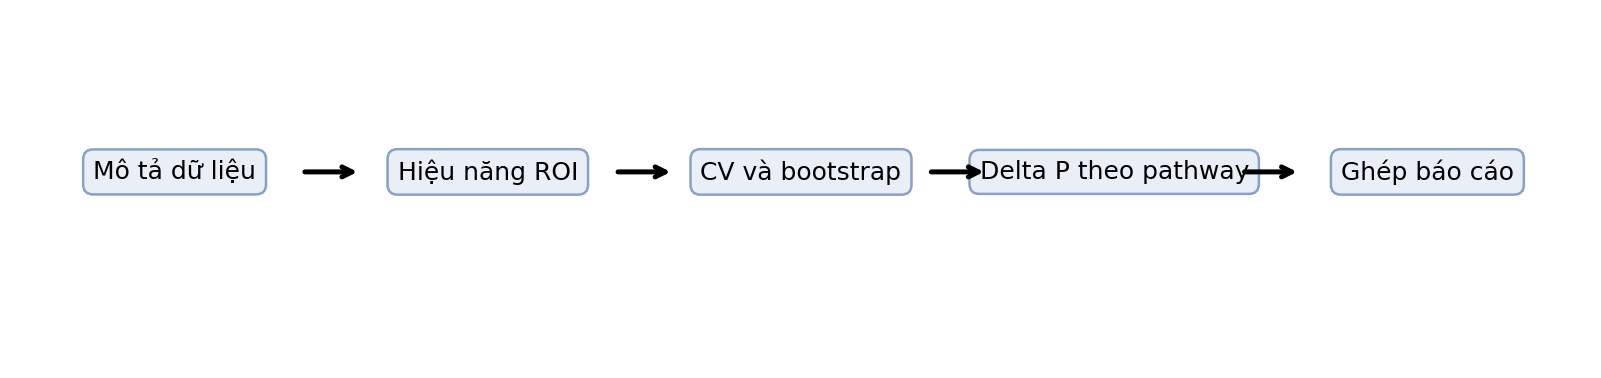

In [4]:
from PIL import Image

figure_files = [
    '_static/figures/day01_age_hist.png',
    '_static/figures/day01_size_box.png',
    '_static/figures/day02_roc_compare.png',
    '_static/figures/day03_cv_auc.png',
    '_static/figures/day03_bootstrap_auc.png',
    '_static/figures/day04_delta_median_bar.png',
    '_static/figures/day04_top_pathway_box.png',
]

for fp in figure_files:
    img = Image.open(fp)
    img.save(output_dir / Path(fp).name)

display(Image.open('_static/figures/day05_pipeline_flow.png'))

## Bước 3 — Viết một đoạn tóm tắt kết quả

Buổi cuối phải tập cho học sinh chuyển từ code sang câu văn ngắn.

In [5]:
summary_text = f'''
Cohort demo gồm {metrics["cohort_n"]} bệnh nhân và tỉ lệ EGFR dương là {metrics["egfr_positive_pct"]} phần trăm.
Trong phần so sánh ROI, ring1 cho AUC cao nhất là {metrics["roi_results"]["ring1"]["auc"]}.
Khi kiểm tra độ ổn định, mean AUC của 5 fold là {metrics["cv_auc_mean"]} và bootstrap CI 95 phần trăm kéo từ {metrics["bootstrap_ci"][0]} đến {metrics["bootstrap_ci"][1]}.
Trong subset NGS, pathway đứng đầu là {metrics["top_pathway"]} với delta median P dương.
Như vậy, bộ kết quả demo đã đủ để học sinh hiểu trọn một vòng phân tích từ mô tả dữ liệu đến radiogenomics.
'''.strip()

(Path(output_dir) / 'summary_note.txt').write_text(summary_text, encoding='utf-8')
print(summary_text)

Cohort demo gồm 200 bệnh nhân và tỉ lệ EGFR dương là 45.5 phần trăm.
Trong phần so sánh ROI, ring1 cho AUC cao nhất là 0.815.
Khi kiểm tra độ ổn định, mean AUC của 5 fold là 0.81 và bootstrap CI 95 phần trăm kéo từ 0.687 đến 0.923.
Trong subset NGS, pathway đứng đầu là PI3K với delta median P dương.
Như vậy, bộ kết quả demo đã đủ để học sinh hiểu trọn một vòng phân tích từ mô tả dữ liệu đến radiogenomics.


## Sản phẩm sau bài học

- Một thư mục output hoàn chỉnh
- Ba file csv chính
- Các hình quan trọng của toàn bộ mini bootcamp
- Một đoạn tóm tắt để dùng trong báo cáo

## Tự kiểm tra

1. Nếu phải nộp poster thì lấy những file nào trong output
2. Nếu phải viết phần kết quả ngắn thì dùng mấy câu nào
3. Nếu muốn thay mô hình khác thì cần kiểm soát lại bước nào